
Para resolverlo de verdad (listados/deslistados masivos), estas son las fuentes que debes usar en este orden:

1. SEC (gratis, oficial, base)

- Mapa ticker↔CIK: https://www.sec.gov/files/company_tickers_exchange.json
- Historial de filings por CIK: https://data.sec.gov/submissions/CIK##########.json
- Doc oficial de acceso EDGAR: https://www.sec.gov/search-filings/edgar-search-assistance/accessing-edgar-data

2. Nasdaq Daily List (oficial exchange, clave para delist reasons y cambios)

- Especificación oficial: https://www.nasdaqtrader.com/content/technicalsupport/specifications/dataproducts/dlcompletespec.pdf
- Esto normalmente va por sFTP con contrato/licencia (no siempre abierto por HTTP).

3. NYSE/CTA symbol files (oficial tape, útil para estado diario y cambios de universo)

- Índice de archivos CTA: https://ftp.nyse.com/cta_symbol_files/

Diagnóstico claro:

- Con solo SEC no vas a llegar al 100% del universo (ya lo viste: faltan CIK, y no todo delist entra limpio por Form 25).
Si quieres, el siguiente paso te lo hago yo: te monto un script único que ingiera esas 3 fuentes, haga reconciliación y te entregue
% cobertura y gap por ticker automáticamente.
  
```sh

```

# 00B · Construcción del universo de tickers desde quotes (reproducible)

Esta celda crea `tickers_universe.txt` partiendo únicamente de las carpetas existentes en `quotes_p95` (fuente raw local).

Qué hace
- Recorre `C:\TSIS_Data\data\quotes_p95`.
- Toma cada carpeta como ticker.
- Normaliza a mayúsculas, deduplica y ordena.
- Guarda el universo en:
`C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\tickers_universe.txt`.

Por qué
Necesitamos una base única de universo para medir cobertura real (`qué tickers tienen listed/delisted`) y para que todos los pasos
siguientes usen exactamente la misma población.

In [4]:
from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\step00b_build_tickers_universe_from_quotes.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

tickers_universe generado: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\tickers_universe.txt
tickers total: 6114
primeros 10: ['AABA', 'AAC', 'AACI', 'AACQ', 'AACT', 'AAGR', 'AAI', 'AAIC', 'AAM', 'AAME']


# 00C · Descarga SEC masiva y merge en eventos oficiales

Esta celda ejecuta la descarga oficial SEC por ticker y fusiona candidatos (`listed/delisted`) en el CSV oficial de eventos.

**Qué hace**
- Usa `tickers_universe.txt`.
- Consulta fuentes oficiales SEC:
- `company_tickers_exchange.json` (ticker ↔ CIK)
- `submissions/CIK##########.json` (filings históricos)
- Genera candidatos en:
`official_ticker_events.sec_candidates.csv`
- Mergea/deduplica en:
`official_ticker_events.csv`.

**Por qué**  
SEC es la base oficial mínima reproducible para construir lifecycle por ticker. Sin este paso no hay evidencia oficial consolidable.

**Nota operativa**  
Hay que definir `USER_AGENT` válido (nombre + email real) para cumplir la política SEC.

In [5]:
### Celda 4 (Lanzadera 00C)

from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\step00c_download_sec_candidates_and_merge.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[00C] Ejecutando descarga SEC + merge...
[00C] Comando: C:\TSIS_Data\v1\backtest_SmallCaps\backtest\Scripts\python.exe C:\TSIS_Data\v1\backtest_SmallCaps\scripts\download_official_events_sec.py --tickers-file C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\tickers_universe.txt --out-candidates-csv C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.sec_candidates.csv --merge-into-official-csv C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.csv --user-agent AlexJ tu_email_real@dominio.com --timeout-sec 30 --sleep-ms 120 --max-tickers 0
[00C] Guardado candidates: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.sec_candidates.csv
[00C] Guardado official merged: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.csv


# 00D · Validación de eventos y compilación de lifecycle oficial

Esta celda valida estructura/calidad de eventos y compila lifecycle por ticker (`list_date`, `delist_date`).

**Qué hace**  
- Lee `official_ticker_events.csv`.
- Valida tipos de evento y fechas.
- Elimina duplicados.
- Compila lifecycle y guarda:
- `official_lifecycle_compiled.csv/.parquet`
- `official_ticker_events.validated.parquet`
- `official_lifecycle_validation_report.json`.

**Por qué**  
Separa claramente:
- evidencia de evento,
- dataset validado,
- lifecycle final usado en análisis.
Así queda trazabilidad y control de calidad para auditoría.

In [6]:
### Celda 6 (Lanzadera 00D)

from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\step00d_build_official_lifecycle_validated.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[00D] Ejecutando validacion + build lifecycle...
[00D] Comando: C:\TSIS_Data\v1\backtest_SmallCaps\backtest\Scripts\python.exe C:\TSIS_Data\v1\backtest_SmallCaps\scripts\build_official_lifecycle.py --events-csv C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.csv --out-lifecycle-csv C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv --out-events-parquet C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.validated.parquet --out-lifecycle-parquet C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.parquet --out-validation-json C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_validation_report.json
[00D] Guardado lifecycle csv: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv
[00D] Guardado validation json: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_validation_report.json


# 00E · Reconciliación multi-fuente y cobertura/gaps por ticker

Esta celda ejecuta la reconciliación final para medir cobertura real del universo y gaps pendientes.

**Qué hace**
- Toma universo (`tickers_universe.txt`) + base SEC (`official_ticker_events.csv`).
- Si existen archivos locales, incorpora:
- Nasdaq Daily List (`data/external/nasdaq/**/*.*`)
- NYSE/CTA symbol files (`data/external/nyse_cta/**/*.*`)
- Revalida eventos y recompila lifecycle.
- Genera outputs en `runs/.../step00e_official_multisource_*`:
- eventos validados multisource,
- lifecycle multisource,
- `coverage_summary`,
- `gaps_by_ticker`,
- reporte de validación.

**Por qué**  
Con SEC sola no llegamos a cobertura completa de delist/list. Este paso cuantifica exactamente cuánto falta y qué tickers faltan,
listo para priorizar ingestión oficial adicional.

In [7]:
### Celda 8 (Lanzadera 00E)

from pathlib import Path
SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\step00e_multisource_reconcile_coverage.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

[00E] Ejecutando reconciliacion multisource...
[00E] Comando: C:\TSIS_Data\v1\backtest_SmallCaps\backtest\Scripts\python.exe C:\TSIS_Data\v1\backtest_SmallCaps\scripts\reconcile_official_events_multisource.py --tickers-file C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\tickers_universe.txt --sec-events-csv C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_ticker_events.csv --nasdaq-glob data/external/nasdaq/**/*.* --nyse-glob data/external/nyse_cta/**/*.* --out-events-csv C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\00_data_certification\official_multisource\step00e_official_multisource_20260301T163854Z\official_ticker_events.multisource.validated.csv --out-events-parquet C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\00_data_certification\official_multisource\step00e_official_multisource_20260301T163854Z\official_ticker_events.multisource.validated.parquet --out-lifecycle-csv C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\00_data_certification\official

RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\00_data_certification\coverage_diagnostics\step00f_coverage_diag_20260301T165833Z
SUMMARY: {'universe_tickers': 6114, 'tickers_with_any_event': 2051, 'tickers_with_listed_event': 2008, 'tickers_with_delist_signal_event': 626, 'tickers_with_both_listed_and_delisted': 583, 'lifecycle_rows': 1970, 'lifecycle_with_delist_date': 544, 'lifecycle_without_delist_date': 1426, 'coverage_any_event_pct': 33.55, 'coverage_listed_event_pct': 32.84, 'coverage_delist_signal_event_pct': 10.24, 'coverage_lifecycle_delist_date_pct': 8.9, 'events_rows': 2636}
GAP_COUNTS: {'gap_missing_any_event': 4062, 'gap_missing_listed_event': 4105, 'gap_missing_delist_signal_event': 5488, 'gap_missing_lifecycle_list_date': 4144, 'gap_missing_lifecycle_delist_date': 5570}
Saved plots:
 - C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\00_data_certification\coverage_diagnostics\step00f_coverage_diag_20260301T165833Z\coverage_core_bars.png
 - C:\TSIS_Data

### Coverage Diagnostics Summary

,universe_tickers,tickers_with_any_event,tickers_with_listed_event,tickers_with_delist_signal_event,tickers_with_both_listed_and_delisted,lifecycle_rows,lifecycle_with_delist_date,lifecycle_without_delist_date,coverage_any_event_pct,coverage_listed_event_pct,coverage_delist_signal_event_pct,coverage_lifecycle_delist_date_pct,events_rows
0,6114,2051,2008,626,583,1970,544,1426,33.55,32.84,10.24,8.9,2636


### Gap Counts

,gap_missing_any_event,gap_missing_listed_event,gap_missing_delist_signal_event,gap_missing_lifecycle_list_date,gap_missing_lifecycle_delist_date
0,4062,4105,5488,4144,5570


### Plots (2 columnas)


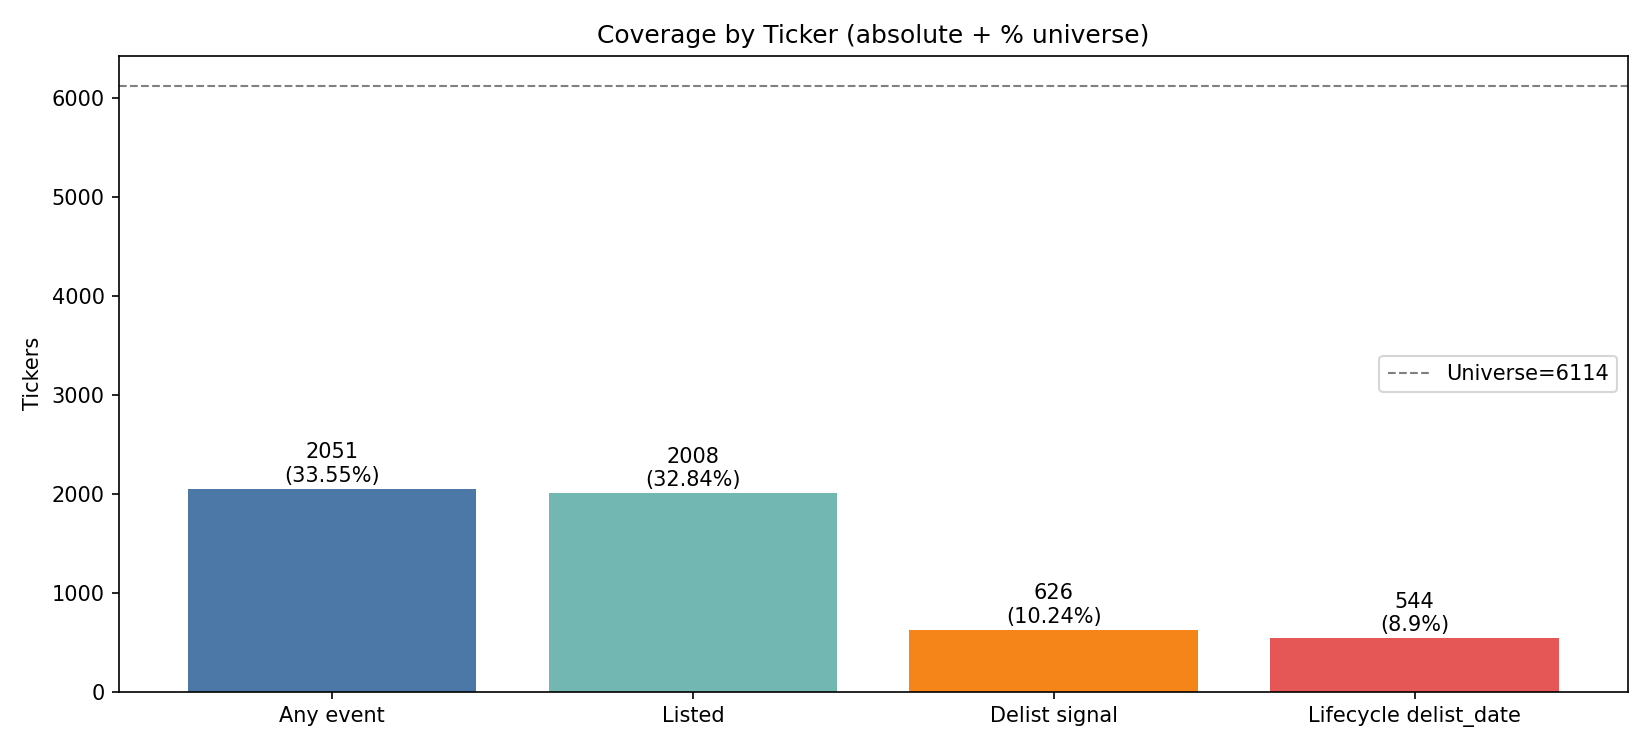
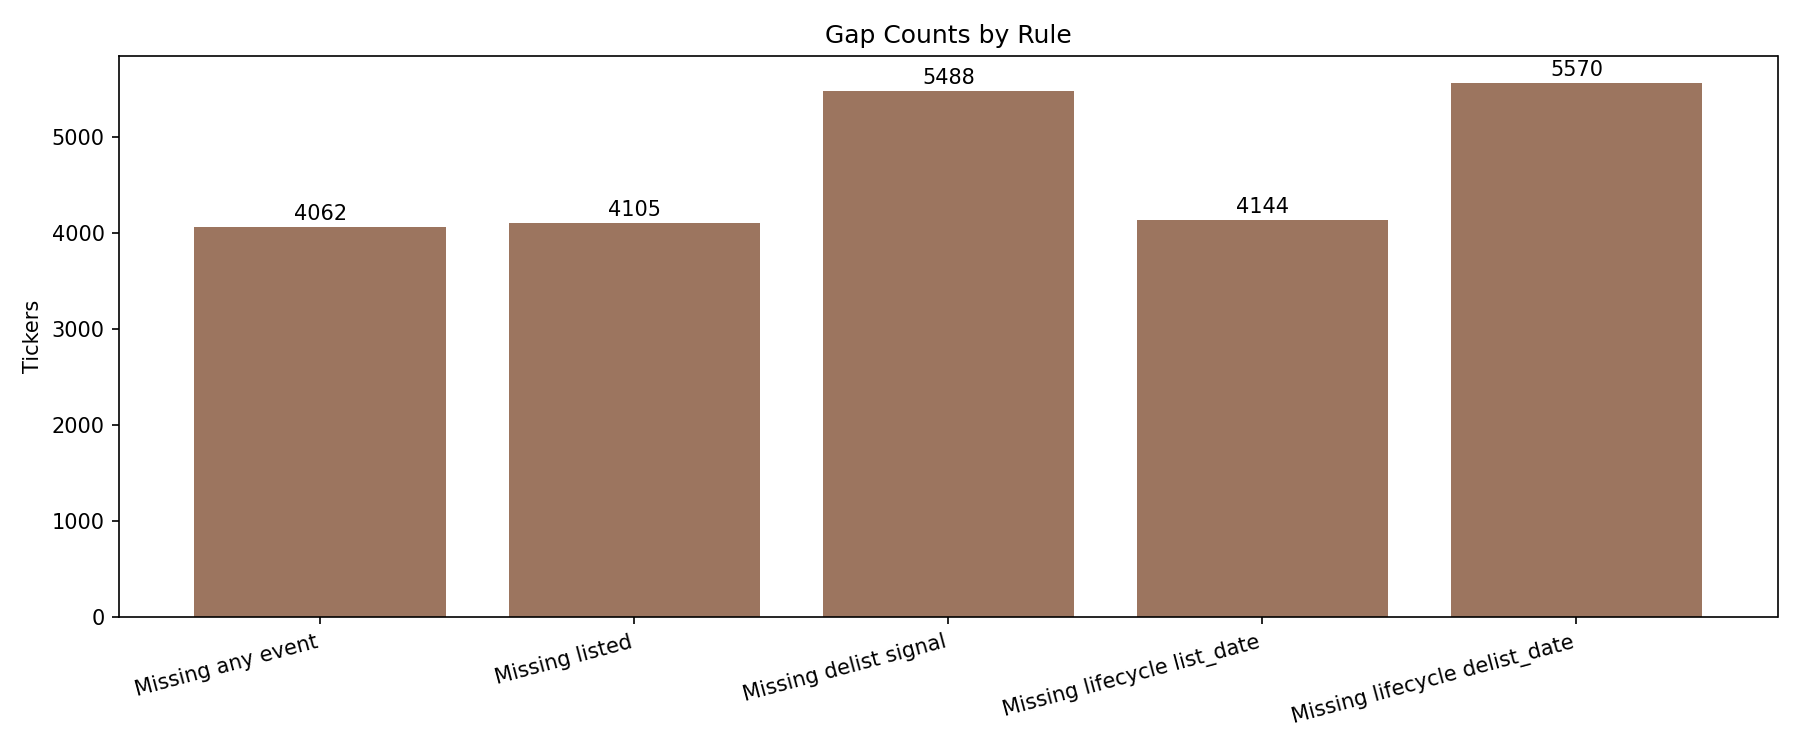
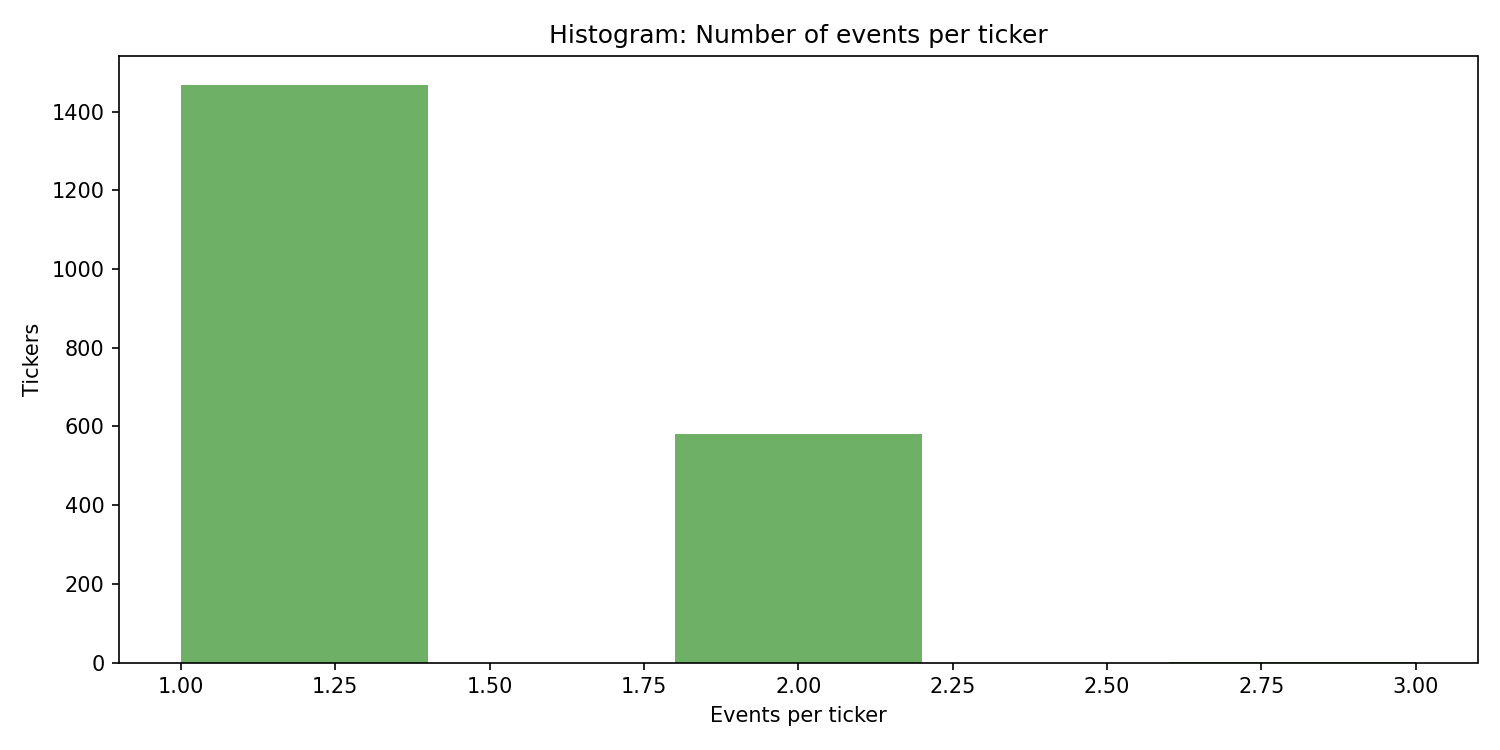
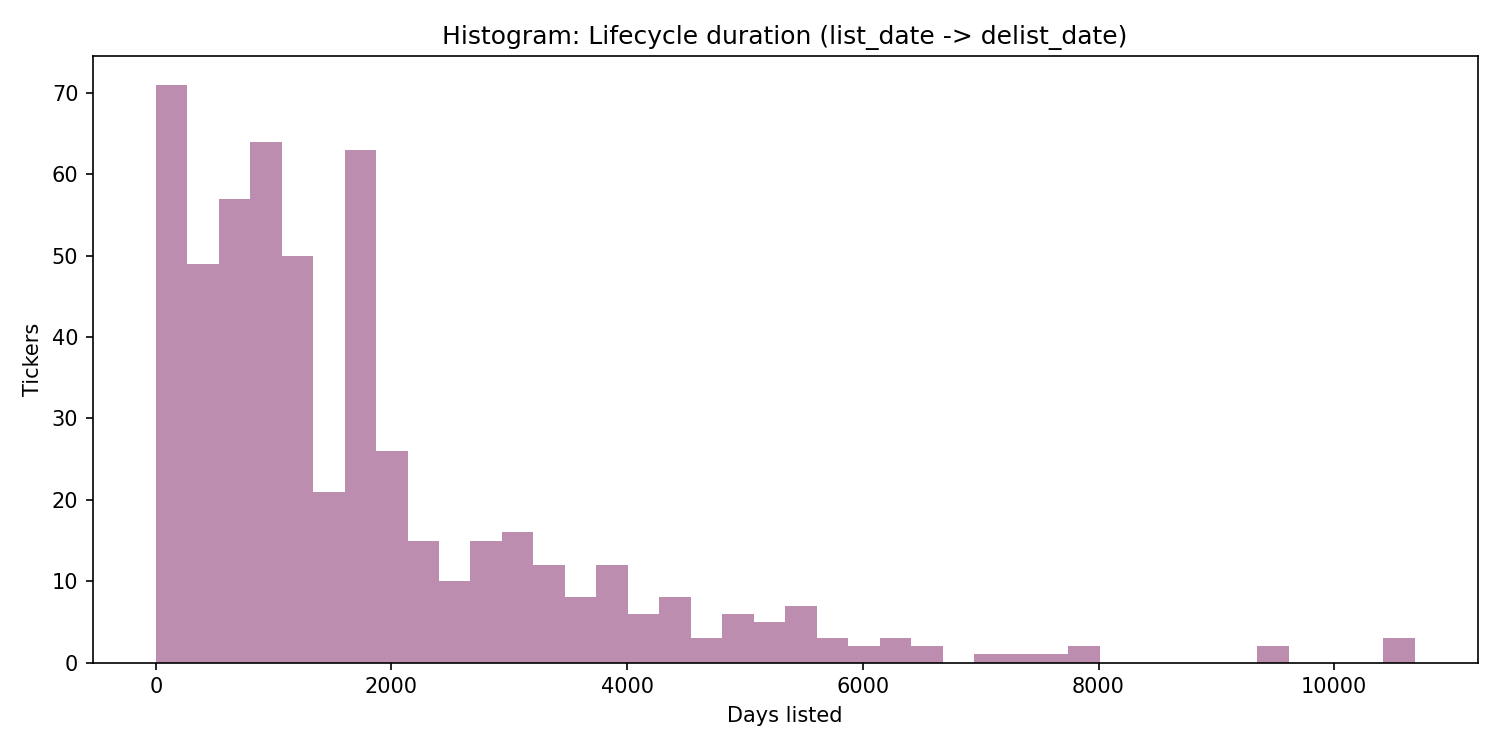
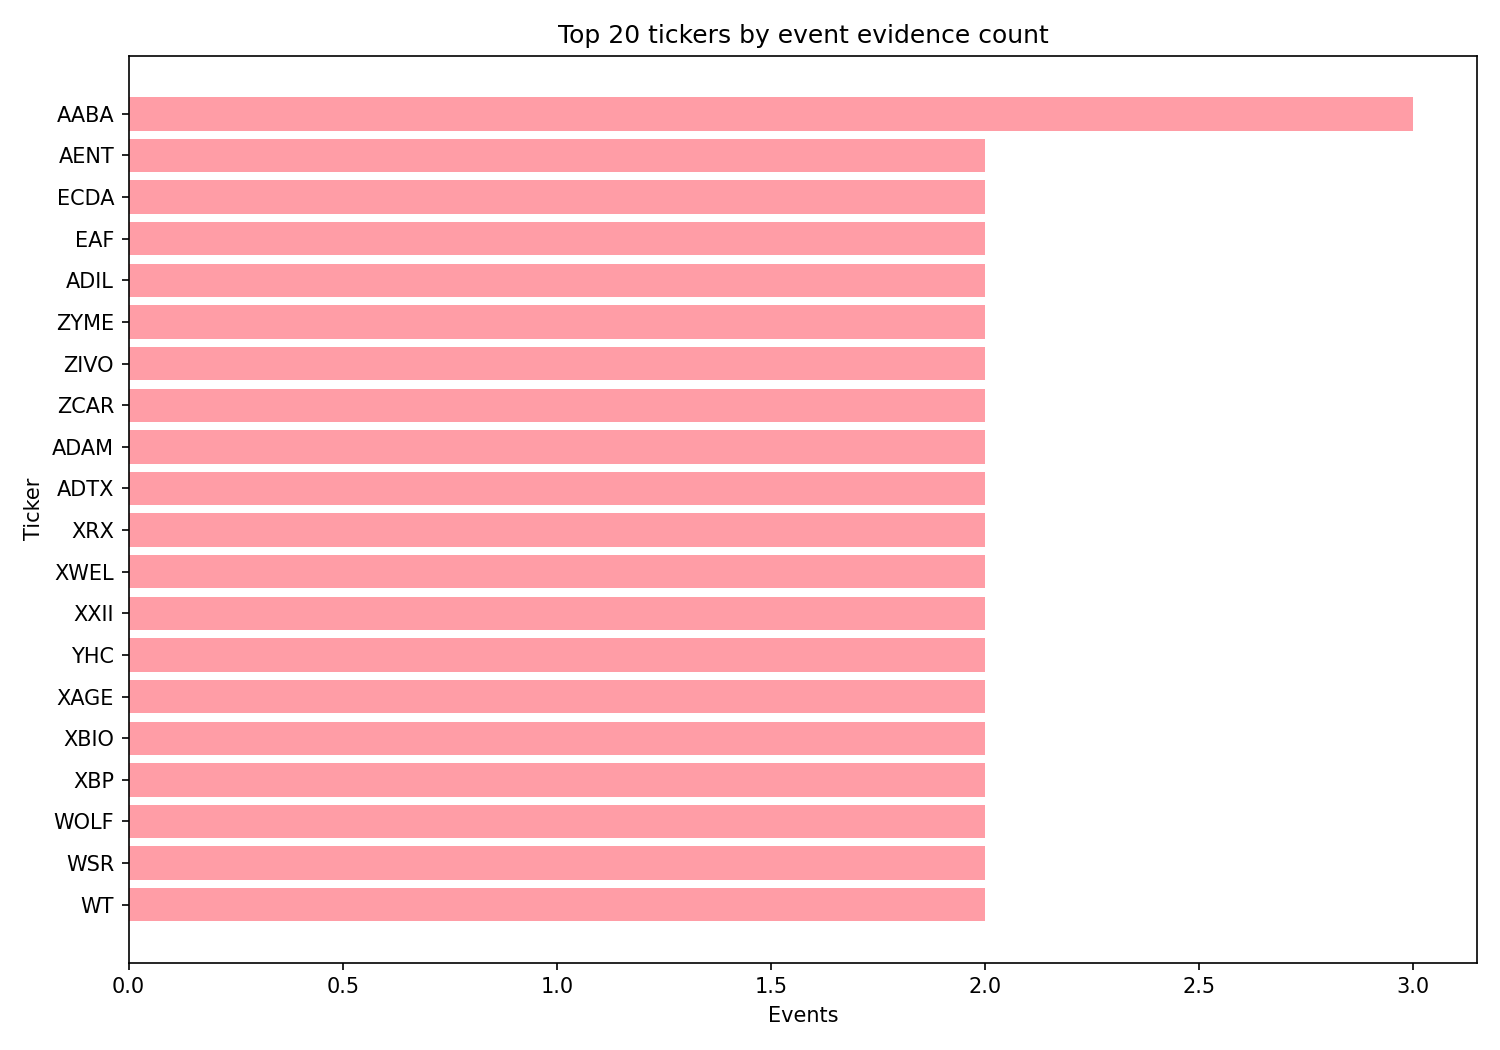

In [10]:
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\step00f_coverage_diagnostics_plots.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

**1. coverage_core_bars.png (Cobertura core)**

- Compara, sobre el universo total (6114), cuántos tickers tienen:
    - algún evento,
    - evento listed,
    - señal delisted,
    - delist_date en lifecycle.
- Lectura actual:
    - Any event: 2051 (33.55%)
    - Listed: 2008 (32.84%)
    - Delist signal: 626 (10.24%)
    - Lifecycle con delist_date: 544 (8.9%)

**2. gaps_bars.png (Gaps por regla)**

- Muestra cuántos tickers faltan por cada condición de cobertura.
- Lectura actual:
    - Missing any event: 4062
    - Missing listed: 4105
    - Missing delist signal: 5488
    - Missing lifecycle list_date: 4144
    - Missing lifecycle delist_date: 5570
- Este gráfico te dice exactamente “dónde está el agujero”.

**3. hist_events_per_ticker.png (Histograma eventos por ticker)**

- Distribuye cuántos eventos tiene cada ticker (1, 2, 3, …).
- Sirve para ver si la evidencia está concentrada en pocos tickers o repartida.
- Si hay mucha masa en 1 evento, significa cobertura superficial; si sube 2+ eventos, mejor trazabilidad.

**4. hist_lifecycle_duration_days.png (Duración listado→deslistado)**

- Solo usa tickers que tienen ambas fechas (list_date y delist_date).
- Eje X: días listada la compañía.
- Eje Y: número de tickers.
- En tu imagen hay cola larga: muchos casos más cortos/medios y pocos outliers muy largos.

**5. top20_tickers_by_events.png (Top 20 por evidencia)**

En tu contexto, “eventos” son hechos oficiales por ticker con fecha que indican estado en mercado.

  Ejemplos:

  1. listed = empieza a cotizar / admisión.
  2. delisted = deja de cotizar.
  3. (a veces) halted, suspended, renamed.

  Cada evento es una fila con:

  - ticker
  - event_type
  - event_date
  - fuente (SEC, Nasdaq, NYSE, etc.)
  - URL/evidencia del documento

  Entonces:

  - “events per ticker = 2” suele significar: ese ticker tiene 1 listed + 1 delisted.
  - “events per ticker = 1” significa que solo tenemos uno de los dos lados (entrada o salida), cobertura incompleta.

  Por eso ese gráfico mide cuánta historia oficial tenemos por ticker, no cuántos trades ni quotes.

---

Devido al bajo % de data que se cubre por esta via, al ser tan bajo, decido cambiar de formula. Voy a descargar data de nuevo de Polygon.  
Plan de actuacion:    

**1. Analiza la data esperada**: por cada carpeta a descargar estudiamos las tablas, atributos e intancias que esperamos tener.  
**2. Revision download data** : En tiempo real, mientras se descargan un agente revisará que la data de atributos e instancias esté completa en el file.   
**3. Estadisticas** : Otro agente en tiempo real, mientras se descarga irá generando estadisticas de lo descargado y revisará que las folders se llenen con files y folders (días/meses/años)  